In [1]:
import os
import glob
import sys

import itertools

import numpy as np
import pandas as pd
import scipy.stats as ss
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm as tqdm_auto
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import pytorch_lightning as pl

from IPython.display import clear_output

In [2]:
# Load all models
from optimus5 import Optimus5PrimeOriginal
from optimus5_25 import Optimus5Prime25
from mttrans import RL_gru
from framepool import FramePool
from dream_wrappers import DreamRNNFacade, DreamAttnFacade

In [3]:
sys.path.append("../../predictor/model/")
import utrdata_cl as utrdata
from pl_regressor import RNARegressor
from legnet_classifier import LegNetClassifier

In [4]:
utr_type = "utr5"
seqsize = 50 if utr_type == "utr5" else 240

## Loading data

In [5]:
PATH_FROM = f"../../predictor/regression_multiple/{utr_type.upper()}_zscores_replicateagg.csv"
df = pd.read_csv(PATH_FROM)

In [6]:
num_classes = df["cell_type"].unique().shape[0]
num_classes

5

In [7]:
splits = dict(tuple(df.groupby('fold')))
for split_df in splits.values():
    split_df.reset_index(drop=True, inplace=True)
splits["test"].head()

,seq,cell_type,fold,1,2,3,4,mass_center,mass_center_mean,diff,zscore,mass_center_std
0,AAACCGAGGCCAGAGTGTCCCCGTGGGCCGAGCGCACTTTTTTCTT...,c1,test,76.676858,77.280305,71.076231,71.867445,2.465254,2.421816,0.043438,0.460575,0.094312
1,AAACCGAGGCCAGAGTGTCCCCGTGGGCCGAGCGCACTTTTTTCTT...,c17,test,79.028058,87.374265,63.447506,53.471756,2.322471,2.421816,-0.099345,-1.053367,0.094312
2,AAACCGAGGCCAGAGTGTCCCCGTGGGCCGAGCGCACTTTTTTCTT...,c2,test,74.376089,76.078916,74.830791,67.914497,2.464814,2.421816,0.042998,0.455914,0.094312
3,AAACCGAGGCCAGAGTGTCCCCGTGGGCCGAGCGCACTTTTTTCTT...,c4,test,57.917050,74.023513,66.633378,66.185816,2.532891,2.421816,0.111074,1.177732,0.094312
4,AAACCGAGGCCAGAGTGTCCCCGTGGGCCGAGCGCACTTTTTTCTT...,c6,test,111.268903,68.903514,67.302508,74.007200,2.323651,2.421816,-0.098165,-1.040854,0.094312


In [8]:
batch_size = 128

In [9]:
num_workers = 32

In [10]:
test_set = utrdata.UTRData(
    df=splits["test"],
    predict_cols=["mass_center"],
    construct_type=utr_type,
    features=("sequence", "conditions"),
    augment=False,
    augment_test_time=False,
    augment_kws=dict(
        extend_left=0,
        extend_right=0,
        shift_left=0,
        shift_right=0,
        revcomp=False,
    ),
)
dl_test = DataLoader(
    test_set,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False,
    drop_last=False
)

parade_test_set = utrdata.UTRData(
    df=splits["test"],
    construct_type=utr_type,
    features=("sequence", "positional", "conditions"),
    augment=False,
    augment_test_time=False,
    augment_kws=dict(
        extend_left=0,
        extend_right=0,
        shift_left=0,
        shift_right=0,
        revcomp=False,
    ),
)
parade_dl_test = DataLoader(
    parade_test_set,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False,
    drop_last=False
)

### Loading models

In [11]:
legnet_checkpoint = glob.glob(f"../../predictor/regression_multiple/saved_models/model-{utr_type}*.ckpt")[0]
model_checkpoints = {os.path.basename(os.path.dirname(path)): path for path in glob.glob(f"./saved_models/{utr_type}/*/*.ckpt")}
model_checkpoints

{'DreamAttnFacade': './saved_models/utr5/DreamAttnFacade/epoch=4-step=13505.ckpt',
 'DreamRNNFacade': './saved_models/utr5/DreamRNNFacade/epoch=16-step=45917.ckpt',
 'Optimus5PrimeOriginal': './saved_models/utr5/Optimus5PrimeOriginal/epoch=12-step=8775.ckpt',
 'FramePool': './saved_models/utr5/FramePool/epoch=10-step=7425.ckpt',
 'Optimus5Prime25': './saved_models/utr5/Optimus5Prime25/epoch=10-step=7425.ckpt',
 'RL_gru': './saved_models/utr5/RL_gru/epoch=99-step=270100.ckpt'}

In [12]:
models = dict()
for model_name, ckpt_path in model_checkpoints.items():
    ckpt = torch.load(ckpt_path)
    loaded_model = RNARegressor(**ckpt["hyper_parameters"])
    loaded_model.load_state_dict(ckpt["state_dict"])
    models[model_name] = loaded_model
legnet_ckpt = torch.load(legnet_checkpoint)
legnet_model = RNARegressor(**legnet_ckpt["hyper_parameters"])
legnet_model.load_state_dict(legnet_ckpt["state_dict"])

<All keys matched successfully>

In [13]:
progressbar_callback = pl.callbacks.TQDMProgressBar(refresh_rate=0.5)
trainer = pl.Trainer(
    callbacks=[progressbar_callback],
    accelerator="gpu",
    devices=[0],
    deterministic=True,
    num_sanity_val_steps=0,
)
result_df = splits["test"][["seq", "cell_type", "mass_center"]].copy()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [14]:
for model_name, model_instance in models.items():
    print(model_name)
    prediction = trainer.predict(model=model_instance, dataloaders=dl_test)
    test_pred, test_real = zip(*prediction)
    test_pred = torch.concat(test_pred).numpy()
    # test_real = torch.concat(test_real).numpy()
    result_df[model_name] = test_pred[:, 0]

DreamAttnFacade


You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Predicting: 0it [00:00, ?it/s]

You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


DreamRNNFacade


...

Optimus5Prime25


Predicting: 0it [00:00, ?it/s]

You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


RL_gru


Predicting: 0it [00:00, ?it/s]

In [15]:
print("LegNetClassifier")
prediction = trainer.predict(model=legnet_model, dataloaders=parade_dl_test)
test_pred, test_real = zip(*prediction)
test_pred = torch.concat(test_pred).numpy()
# test_real = torch.concat(test_real).numpy()
result_df["LegNetClassifier"] = test_pred[:, 1]
result_df["LegNetClassifier_delta"] = test_pred[:, 0]

You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


LegNetClassifier


Predicting: 0it [00:00, ?it/s]

In [16]:
result_df_r = pd.concat({"pred_mass_center": result_df.drop(["seq", "cell_type", "mass_center"], axis=1)}, axis=1)
for i, col in enumerate(["seq", "cell_type", "mass_center"]):
    result_df_r.insert(i, col, result_df[col])
result_df_r

seq cell_type  \
                                                                     
0      AAACCGAGGCCAGAGTGTCCCCGTGGGCCGAGCGCACTTTTTTCTT...        c1   
1      AAACCGAGGCCAGAGTGTCCCCGTGGGCCGAGCGCACTTTTTTCTT...       c17   
2      AAACCGAGGCCAGAGTGTCCCCGTGGGCCGAGCGCACTTTTTTCTT...        c2   
3      AAACCGAGGCCAGAGTGTCCCCGTGGGCCGAGCGCACTTTTTTCTT...        c4   
4      AAACCGAGGCCAGAGTGTCCCCGTGGGCCGAGCGCACTTTTTTCTT...        c6   
...                                                  ...       ...   
10795  TTTTCCCAGGGCGTGGGCTTGCCCCGCGCGTGTCTGTGGAGGGCGG...        c1   
10796  TTTTCCCAGGGCGTGGGCTTGCCCCGCGCGTGTCTGTGGAGGGCGG...       c17   
10797  TTTTCCCAGGGCGTGGGCTTGCCCCGCGCGTGTCTGTGGAGGGCGG...        c2   
10798  TTTTCCCAGGGCGTGGGCTTGCCCCGCGCGTGTCTGTGGAGGGCGG...        c4   
10799  TTTTCCCAGGGCGTGGGCTTGCCCCGCGCGTGTCTGTGGAGGGCGG...        c6   

      mass_center pred_mass_center                                       \
                   DreamAttnFacade DreamRNNFacade Optimus5PrimeOriginal   
0        2.465254         2.472427       2.463316              2.474938   
1        2.322471         2.465312       2.456888              2.492393   
2        2.464814         2.538974       2.530236              2.528852   
3        2.532891         2.464214       2.479174              2.502334   
4        2.323651         2.419384       2.448068              2.477196   
...           ...              ...            ...                   ...   
10795    2.503601         2.589677       2.567483              2.666178   
10796    2.479266         2.647539       2.658005              2.830161   
10797    2.483830         2.575839       2.523145              2.623264   
10798    2.419081         2.618670       2.597168              2.718183   
10799    2.360696         2.535925       2.545113              2.676289   

                                                            \
      FramePool Optimus5Prime25    RL_gru LegNetClassifier   
0      2.392160        2.373484  2.537323         2.540992   
1      2.352106        2.403961  2.541064         2.526518   
2      2.473049        2.395098  2.541674         2.550834   
3      2.406403        2.371149  2.526063         2.491250   
4      2.306729        2.370543  2.551649         2.480797   
...         ...             ...       ...              ...   
10795  2.584878        2.446221  2.580428         2.563044   
10796  2.682558        2.513063  2.644888         2.674348   
10797  2.545729        2.402609  2.568615         2.548767   
10798  2.637728        2.454372  2.605288         2.583612   
10799  2.604790        2.425281  2.597354         2.548970   

                              
      LegNetClassifier_delta  
0                   0.004116  
1                  -0.000910  
2                   0.028963  
3                  -0.003857  
4                  -0.036074  
...                      ...  
10795              -0.011249  
10796               0.059039  
10797              -0.025707  
10798               0.014399  
10799              -0.035478  

[10800 rows x 11 columns]

In [17]:
result_df_r.to_parquet(f"benchmark_preds_{utr_type}.parquet")

In [18]:
correlations = result_df.groupby("cell_type")[["mass_center"] + list(models.keys()) + ["LegNetClassifier"]].corr()["mass_center"].unstack(0).drop("mass_center", axis=0)
correlations["mean"] = result_df.groupby("seq")[["mass_center"] + list(models.keys()) + ["LegNetClassifier"]].mean().corr()["mass_center"].drop("mass_center")
correlations

cell_type,c1,c17,c2,c4,c6,mean
DreamAttnFacade,0.755491,0.724681,0.770769,0.613609,0.784167,0.803944
DreamRNNFacade,0.718392,0.716681,0.711985,0.592859,0.755290,0.777503
Optimus5PrimeOriginal,0.733359,0.706999,0.751330,0.608456,0.756326,0.789771
FramePool,0.733290,0.716249,0.756748,0.624333,0.753522,0.796032
Optimus5Prime25,0.706215,0.680599,0.701874,0.587727,0.737013,0.757342
RL_gru,0.687203,0.675488,0.694425,0.585080,0.733026,0.753667
LegNetClassifier,0.774258,0.741030,0.788963,0.647458,0.781765,0.823008


<Axes: ylabel='cell_type'>

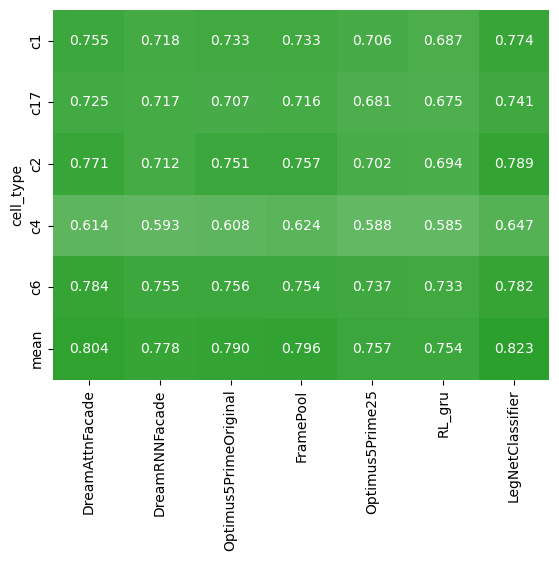

In [19]:
sns.heatmap(correlations.T, cmap=sns.color_palette("light:C2", n_colors=1000, as_cmap=True), vmin=0,
            annot=True, fmt=".3f", cbar=False)

In [20]:
correlations.mean(axis=1).sort_values(ascending=False)

LegNetClassifier         0.759414
DreamAttnFacade          0.742110
FramePool                0.730029
Optimus5PrimeOriginal    0.724373
DreamRNNFacade           0.712118
Optimus5Prime25          0.695128
RL_gru                   0.688148
dtype: float64

In [21]:
list(zip(correlations.columns, correlations.index[correlations.values.argmax(axis=0)]))

[('c1', 'LegNetClassifier'),
 ('c17', 'LegNetClassifier'),
 ('c2', 'LegNetClassifier'),
 ('c4', 'LegNetClassifier'),
 ('c6', 'DreamAttnFacade'),
 ('mean', 'LegNetClassifier')]

---